In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal

## Libs for Agents
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

/tmp/ipykernel_19789/1724199225.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


In [3]:
## coding, google_search, weather

class FlowState(BaseModel):
    question:str = Field(description="User Asked Question")
    category : Literal['coding', 'google_search', 'weather'] = Field(default="google_search")
    answer : str = Field(default="")

In [4]:
class QuestionCategory(BaseModel):
    category : Literal['coding', 'google_search', 'weather'] = Field(default="google_search",description="Question Category")

In [5]:

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [13]:
### Define Your Agents - googleSearchAgent, Weather Agent
search = GoogleSerperAPIWrapper()
tools = [search.run]

google_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a agent and can search for any question on google."
)


## Weather Agent
@tool
def get_weather(city:str):
    """It provide real time weather details for any city"""
    return f"The current temperature in {city} is 23.C"

weather_agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a agent and can provide real time weather details."
)

In [7]:
def check_question_category(state:FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of my question, question is : {state.question}. If you are not sure then just give 'google_search' as a category")
    state.category = res.category
    return state


def route(state:FlowState) -> Literal['coding', 'google_search', 'weather']:
    return state.category


def coding_node(state:FlowState) -> FlowState:
    print("Coding NODE...")
    res = llm.invoke(f"You are a coding expert: {state.question}")
    state.answer = res.content
    return state


def weather_node(state:FlowState) -> FlowState:
    res = weather_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state


def google_search_node(state:FlowState) -> FlowState:
    res = google_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state

In [8]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()

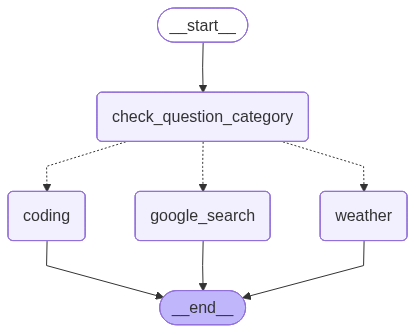

In [9]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [14]:
response = graph.invoke({"question":"address of white house?"})
print(response)

{'question': 'address of white house?', 'category': 'google_search', 'answer': 'The address of the White House is 1600 Pennsylvania Avenue NW, Washington, D.C. 20500.'}
